In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist


In [2]:
calls = pd.read_pickle("/ceph/MethDev/pbio/kay/data/calls_filtered.pkl")
calls['chr'] = calls['chr'].astype('int64')
calls

,chr,start,end
0,1,76901,77000
1,1,77001,77100
2,1,77201,77300
3,1,281801,281900
4,1,281901,282000
...,...,...,...
3352,5,26885901,26886000
3353,5,26886001,26886100
3354,5,26886101,26886200
3355,5,26886201,26886300


In [3]:
win_list = calls[["chr", "start", "end"]]
win_list

,chr,start,end
0,1,76901,77000
1,1,77001,77100
2,1,77201,77300
3,1,281801,281900
4,1,281901,282000
...,...,...,...
3352,5,26885901,26886000
3353,5,26886001,26886100
3354,5,26886101,26886200
3355,5,26886201,26886300


In [4]:
calls['chr']

0       1
1       1
2       1
3       1
4       1
       ..
3352    5
3353    5
3354    5
3355    5
3356    5
Name: chr, Length: 3357, dtype: int64

In [5]:
df = pd.read_csv('/ceph/MethDev/pbio/kay/data/annotated_filtered_col.CG_2.fast.tsv', sep='\t')      # or read_parquet / feather …
df

,cluster,chr,start,end,score,c,t,n,flag_euc_gene,flag_het_gene,flag_euc_TE,flag_het_TE,score_masked
0,0,1,101,200,0.8951,350,41,6,False,False,False,False,0.8951
1,0,1,301,400,0.5487,62,51,2,False,False,False,False,0.5487
2,0,1,401,500,0.8246,47,10,1,False,False,False,False,0.8246
3,0,1,501,600,0.7206,98,38,3,False,False,False,False,0.7206
4,0,1,601,700,0.8982,203,23,6,False,False,False,False,0.8982
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5925984,16,5,26974801,26974900,0.8462,22,4,7,False,False,False,False,0.8462
5925985,16,5,26974901,26975000,0.7500,3,1,2,False,False,False,False,NaN
5925986,16,5,26975101,26975200,1.0000,4,0,4,False,False,False,False,NaN
5925987,16,5,26975201,26975300,1.0000,8,0,8,False,False,False,False,1.0000


In [6]:
df_sub = (df
          .merge(calls, on=['chr','start','end'], how='inner')
          .copy())
df_sub

,cluster,chr,start,end,score,c,t,n,flag_euc_gene,flag_het_gene,flag_euc_TE,flag_het_TE,score_masked
0,0,1,76901,77000,0.9121,83,8,2,False,False,True,False,0.9121
1,1,1,76901,77000,0.8169,58,13,2,False,False,True,False,0.8169
2,2,1,76901,77000,0.9750,39,1,2,False,False,True,False,0.9750
3,3,1,76901,77000,0.8000,20,5,2,False,False,True,False,0.8000
4,4,1,76901,77000,0.5200,13,12,2,False,False,True,False,0.5200
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56833,12,5,26886301,26886400,0.6250,15,9,8,True,False,False,False,0.6250
56834,13,5,26886301,26886400,0.0938,3,29,8,True,False,False,False,0.0938
56835,14,5,26886301,26886400,0.2857,2,5,4,True,False,False,False,0.2857
56836,15,5,26886301,26886400,0.9000,9,1,7,True,False,False,False,0.9000


In [7]:
df_sub.iloc[:15]

,cluster,chr,start,end,score,c,t,n,flag_euc_gene,flag_het_gene,flag_euc_TE,flag_het_TE,score_masked
0,0,1,76901,77000,0.9121,83,8,2,False,False,True,False,0.9121
1,1,1,76901,77000,0.8169,58,13,2,False,False,True,False,0.8169
2,2,1,76901,77000,0.9750,39,1,2,False,False,True,False,0.9750
3,3,1,76901,77000,0.8000,20,5,2,False,False,True,False,0.8000
4,4,1,76901,77000,0.5200,13,12,2,False,False,True,False,0.5200
5,5,1,76901,77000,1.0000,16,0,2,False,False,True,False,1.0000
6,6,1,76901,77000,0.5263,10,9,2,False,False,True,False,0.5263
7,7,1,76901,77000,0.8519,23,4,2,False,False,True,False,0.8519
8,8,1,76901,77000,0.6000,3,2,2,False,False,True,False,0.6000
9,9,1,76901,77000,0.6250,5,3,2,False,False,True,False,0.6250


In [8]:
val_col = 'score_masked'
# Pivot to matrix
mat = (df_sub
       .pivot_table(index=['chr','start','end'],
                    columns='cluster',
                    values=val_col,
                    aggfunc='first')
       .sort_index())

# Attach row metadata for colors
row_meta = (win_list.set_index(['chr','start','end'])
                     .reindex(mat.index))

mat

cluster                    0       1       2       3       4       5       6   \
chr start    end                                                                
1   76901    77000     0.9121  0.8169  0.9750  0.8000  0.5200  1.0000  0.5263   
    77001    77100     0.8858  0.8272  0.9014  0.9194  0.2636  0.8718  0.5462   
    77201    77300     0.9338  0.9451  0.8760  0.9850  0.3282  0.9259  0.8276   
    281801   281900    0.9792  0.9536  0.8832  0.9474  0.9422  0.9367  0.9035   
    281901   282000    0.9435  0.9196  0.8178  0.9322  0.8182  0.9545  0.9155   
...                       ...     ...     ...     ...     ...     ...     ...   
5   26885901 26886000  0.5080  0.4708  0.4770  0.5000  0.2280  0.5816  0.3366   
    26886001 26886100  0.6806  0.5310  0.5443  0.7500  0.3229  0.7500  0.5122   
    26886101 26886200  0.5676  0.5800  0.4898  0.5857  0.2765  0.6538  0.4140   
    26886201 26886300  0.5074  0.5028  0.4603  0.5647  0.2360  0.4138  0.2471   
    26886301 26886400  0.5933  0.5308  0.4818  0.5657  0.1942  0.4535  0.2333   

cluster                    7       8       9       10      11      12      13  \
chr start    end                                                                
1   76901    77000     0.8519  0.6000  0.6250     NaN  0.8571  0.8000     NaN   
    77001    77100     0.8105  0.4000  0.8649  0.6957  0.8974  0.7391  0.3667   
    77201    77300     0.8480  0.5741  1.0000  0.5857  1.0000  0.5625  0.3810   
    281801   281900    0.9680  1.0000  0.7500  0.9512  0.8421  0.7857  0.9286   
    281901   282000    0.8961  0.9189  0.7273  0.8333  0.8679  1.0000  0.8919   
...                       ...     ...     ...     ...     ...     ...     ...   
5   26885901 26886000  0.2143  0.3565  0.6304  0.4000  0.5179  0.3333  0.1566   
    26886001 26886100  0.4070  0.4750  0.9091  0.4000  0.7222  0.4000  0.3939   
    26886101 26886200  0.4207  0.3614  0.5098  0.4595  0.4200  0.4667  0.3784   
    26886201 26886300  0.3580  0.2000  0.4324  0.5714  0.4706  0.4783  0.2258   
    26886301 26886400  0.4235  0.4127  0.4500  0.5200  0.6818  0.6250  0.0938   

cluster                    14      15      16  
chr start    end                               
1   76901    77000        NaN     NaN     NaN  
    77001    77100     0.9130  0.8750  0.8000  
    77201    77300     0.7241  0.9583  0.8846  
    281801   281900    0.9091  0.7391  0.9600  
    281901   282000    0.9714  0.7500  0.9677  
...                       ...     ...     ...  
5   26885901 26886000  0.3929  0.7000     NaN  
    26886001 26886100     NaN  1.0000  1.0000  
    26886101 26886200     NaN  0.6000  0.5000  
    26886201 26886300  0.7273  0.6667  0.6667  
    26886301 26886400  0.2857  0.9000  0.6667  

[3357 rows x 17 columns]

In [9]:
row_meta

Empty DataFrame
Columns: []
Index: [(1, 76901, 77000), (1, 77001, 77100), (1, 77201, 77300), (1, 281801, 281900), (1, 281901, 282000), (1, 282601, 282700), (1, 282701, 282800), (1, 394101, 394200), (1, 394201, 394300), (1, 394401, 394500), (1, 394501, 394600), (1, 394601, 394700), (1, 394701, 394800), (1, 394801, 394900), (1, 394901, 395000), (1, 395001, 395100), (1, 395101, 395200), (1, 395201, 395300), (1, 705001, 705100), (1, 705101, 705200), (1, 754701, 754800), (1, 754801, 754900), (1, 962201, 962300), (1, 962401, 962500), (1, 962501, 962600), (1, 1042001, 1042100), (1, 1042201, 1042300), (1, 1199601, 1199700), (1, 1199701, 1199800), (1, 1295101, 1295200), (1, 1295201, 1295300), (1, 1295301, 1295400), (1, 1489101, 1489200), (1, 1489301, 1489400), (1, 1610001, 1610100), (1, 1610101, 1610200), (1, 2265501, 2265600), (1, 2265601, 2265700), (1, 2265901, 2266000), (1, 2266001, 2266100), (1, 2266101, 2266200), (1, 2266301, 2266400), (1, 2267701, 2267800), (1, 2267901, 2268000), (1, 2268001, 2268100), (1, 2309901, 2310000), (1, 2310001, 2310100), (1, 2310101, 2310200), (1, 2415101, 2415200), (1, 2415201, 2415300), (1, 2481001, 2481100), (1, 2481101, 2481200), (1, 2481201, 2481300), (1, 2481401, 2481500), (1, 2481601, 2481700), (1, 2572701, 2572800), (1, 2572801, 2572900), (1, 2673201, 2673300), (1, 2673301, 2673400), (1, 2673401, 2673500), (1, 2674101, 2674200), (1, 2674301, 2674400), (1, 2674401, 2674500), (1, 2831001, 2831100), (1, 2831101, 2831200), (1, 2831201, 2831300), (1, 2877701, 2877800), (1, 2877801, 2877900), (1, 2953701, 2953800), (1, 2953801, 2953900), (1, 2954101, 2954200), (1, 2954301, 2954400), (1, 3054701, 3054800), (1, 3054901, 3055000), (1, 3327001, 3327100), (1, 3327101, 3327200), (1, 3614201, 3614300), (1, 3614301, 3614400), (1, 3618601, 3618700), (1, 3618701, 3618800), (1, 3797801, 3797900), (1, 3797901, 3798000), (1, 3802901, 3803000), (1, 3803001, 3803100), (1, 3819701, 3819800), (1, 3819801, 3819900), (1, 3819901, 3820000), (1, 3820001, 3820100), (1, 3820101, 3820200), (1, 3820201, 3820300), (1, 3820301, 3820400), (1, 3841701, 3841800), (1, 3841801, 3841900), (1, 3842001, 3842100), (1, 3842101, 3842200), (1, 3842201, 3842300), (1, 4002901, 4003000), (1, 4003001, 4003100), (1, 4061601, 4061700), (1, 4061801, 4061900), ...]

[3357 rows x 0 columns]

In [10]:
# Center per row (subtract row median so 0 = typical for that window)
row_med = np.nanmedian(mat.values, axis=1, keepdims=True)
mat_centered = mat.values - row_med


row_std = np.nanstd(mat.values, axis=1, keepdims=True)
mat_centered = mat_centered / np.where(row_std==0, 1, row_std)
mat_centered = pd.DataFrame(mat_centered, index=mat.index, columns=mat.columns)
mat_centered

cluster                      0         1         2         3         4   \
chr start    end                                                          
1   76901    77000     0.650078  0.052997  1.044578 -0.052997 -1.809118   
    77001    77100     0.284154  0.000000  0.359799  0.447082 -2.732921   
    77201    77300     0.272759  0.326084  0.000000  0.514373 -2.585077   
    281801   281900    0.551399  0.219262 -0.694114  0.138823  0.071358   
    281901   282000    0.372389  0.054528 -1.299371  0.222103 -1.294051   
...                         ...       ...       ...       ...       ...   
5   26885901 26886000  0.493626  0.240694  0.282849  0.439232 -1.410167   
    26886001 26886100  0.661483 -0.030772  0.030772  0.982622 -0.993728   
    26886101 26886200  0.914589  1.041516  0.118226  1.099862 -2.065119   
    26886201 26886300  0.235371  0.205949 -0.065878  0.601858 -1.500489   
    26886301 26886400  0.576461  0.253333  0.000000  0.433767 -1.486907   

cluster                      5         6         7         8         9   \
chr start    end                                                          
1   76901    77000     1.201375 -1.769606  0.272512 -1.307369 -1.150573   
    77001    77100     0.216267 -1.362581 -0.080979 -2.071512  0.182809   
    77201    77300     0.235479 -0.228400 -0.132132 -1.424671  0.585158   
    281801   281900    0.000000 -0.430740  0.406089  0.821260 -2.422264   
    281901   282000    0.518685  0.000000 -0.258012  0.045219 -2.502985   
...                         ...       ...       ...       ...       ...   
5   26885901 26886000  0.994052 -0.671767 -1.503317 -0.536462  1.325856   
    26886001 26886100  0.982622 -0.117767 -0.604566 -0.289905  1.718837   
    26886101 26886200  1.796935 -0.657665 -0.589084 -1.196080  0.322947   
    26886201 26886300 -0.363290 -1.429494 -0.720183 -1.730743 -0.244325   
    26886301 26886400 -0.146312 -1.284758 -0.301414 -0.357251 -0.164408   

cluster                      10        11        12        13        14  \
chr start    end                                                          
1   76901    77000          NaN  0.305126 -0.052997       NaN       NaN   
    77001    77100    -0.637649  0.340403 -0.427201 -2.232985  0.416048   
    77201    77300    -1.369930  0.585158 -1.479412 -2.335913 -0.716819   
    281801   281900    0.188124 -1.227350 -1.959089 -0.105090 -0.358085   
    281901   282000   -1.093227 -0.633061  1.123816 -0.313871  0.743448   
...                         ...       ...       ...       ...       ...   
5   26885901 26886000 -0.240694  0.560939 -0.694205 -1.895634 -0.288969   
    26886001 26886100 -0.636958  0.853981 -0.636958 -0.665185       NaN   
    26886101 26886200 -0.191926 -0.596249 -0.118226 -1.022068       NaN   
    26886201 26886300  0.644711  0.000000  0.049249 -1.565728  1.641839   
    26886301 26886400  0.197496  1.034010  0.740351 -2.005980 -1.013847   

cluster                      15        16  
chr start    end                           
1   76901    77000          NaN       NaN  
    77001    77100     0.231784 -0.131894  
    77201    77300     0.388375  0.040584  
    281801   281900   -2.563682  0.302296  
    281901   282000   -2.201084  0.694239  
...                         ...       ...  
5   26885901 26886000  1.799084       NaN  
    26886001 26886100  2.139465  2.139465  
    26886101 26886200  1.246237  0.222634  
    26886201 26886300  1.254245  1.254245  
    26886301 26886400  2.162116  0.955943  

[3357 rows x 17 columns]

In [24]:
mat

cluster                    0       1       2       3       4       5       6   \
chr start    end                                                                
1   76901    77000     0.9121  0.8169  0.9750  0.8000  0.5200  1.0000  0.5263   
    77001    77100     0.8858  0.8272  0.9014  0.9194  0.2636  0.8718  0.5462   
    77201    77300     0.9338  0.9451  0.8760  0.9850  0.3282  0.9259  0.8276   
    281801   281900    0.9792  0.9536  0.8832  0.9474  0.9422  0.9367  0.9035   
    281901   282000    0.9435  0.9196  0.8178  0.9322  0.8182  0.9545  0.9155   
...                       ...     ...     ...     ...     ...     ...     ...   
5   26885901 26886000  0.5080  0.4708  0.4770  0.5000  0.2280  0.5816  0.3366   
    26886001 26886100  0.6806  0.5310  0.5443  0.7500  0.3229  0.7500  0.5122   
    26886101 26886200  0.5676  0.5800  0.4898  0.5857  0.2765  0.6538  0.4140   
    26886201 26886300  0.5074  0.5028  0.4603  0.5647  0.2360  0.4138  0.2471   
    26886301 26886400  0.5933  0.5308  0.4818  0.5657  0.1942  0.4535  0.2333   

cluster                    7       8       9       10      11      12      13  \
chr start    end                                                                
1   76901    77000     0.8519  0.6000  0.6250     NaN  0.8571  0.8000     NaN   
    77001    77100     0.8105  0.4000  0.8649  0.6957  0.8974  0.7391  0.3667   
    77201    77300     0.8480  0.5741  1.0000  0.5857  1.0000  0.5625  0.3810   
    281801   281900    0.9680  1.0000  0.7500  0.9512  0.8421  0.7857  0.9286   
    281901   282000    0.8961  0.9189  0.7273  0.8333  0.8679  1.0000  0.8919   
...                       ...     ...     ...     ...     ...     ...     ...   
5   26885901 26886000  0.2143  0.3565  0.6304  0.4000  0.5179  0.3333  0.1566   
    26886001 26886100  0.4070  0.4750  0.9091  0.4000  0.7222  0.4000  0.3939   
    26886101 26886200  0.4207  0.3614  0.5098  0.4595  0.4200  0.4667  0.3784   
    26886201 26886300  0.3580  0.2000  0.4324  0.5714  0.4706  0.4783  0.2258   
    26886301 26886400  0.4235  0.4127  0.4500  0.5200  0.6818  0.6250  0.0938   

cluster                    14      15      16  
chr start    end                               
1   76901    77000        NaN     NaN     NaN  
    77001    77100     0.9130  0.8750  0.8000  
    77201    77300     0.7241  0.9583  0.8846  
    281801   281900    0.9091  0.7391  0.9600  
    281901   282000    0.9714  0.7500  0.9677  
...                       ...     ...     ...  
5   26885901 26886000  0.3929  0.7000     NaN  
    26886001 26886100     NaN  1.0000  1.0000  
    26886101 26886200     NaN  0.6000  0.5000  
    26886201 26886300  0.7273  0.6667  0.6667  
    26886301 26886400  0.2857  0.9000  0.6667  

[3357 rows x 17 columns]

In [23]:
mat.iloc[0]

cluster
0     0.9121
1     0.8169
2     0.9750
3     0.8000
4     0.5200
5     1.0000
6     0.5263
7     0.8519
8     0.6000
9     0.6250
10       NaN
11    0.8571
12    0.8000
13       NaN
14       NaN
15       NaN
16       NaN
Name: (1, 76901, 77000), dtype: float64

In [20]:
np.nanstd(mat.iloc[0])

0.15944230648489197

In [21]:
np.nanmean(mat.iloc[0])

0.7736916666666667

In [11]:
#mat_centered.fillna(0.0) #else sns plot will produce error

In [29]:

# # mat: windows × clusters methylation matrix with NaNs allowed
# # (build pivot as before into `mat`, then optional row-centering)
# row_med = np.nanmedian(mat.values, axis=1, keepdims=True)
# mat_centered = pd.DataFrame(mat.values - row_med, index=mat.index, columns=mat.columns)

# # ---- 1) Build a distance-friendly copy (no NaNs) for clustering only ----
# # Use z-scored rows (≈ correlation) and fill NaNs with 0 AFTER z-scoring
# row_mean = np.nanmean(mat_centered.values, axis=1, keepdims=True)
# row_std  = np.nanstd(mat_centered.values, axis=1, keepdims=True)
# mat_z = (mat_centered.values - row_mean) / np.where(row_std==0, 1, row_std)
# mat_z = np.nan_to_num(mat_z, nan=0.0)   # fill remaining NaNs with 0 for distances

# # Compute linkages (Euclidean on z-scores works well and avoids NaN distances)
# row_link = linkage(pdist(mat_z, metric='euclidean'), method='average')
# col_link = linkage(pdist(mat_z.T, metric='euclidean'), method='average')

# # ---- 2) Make a cmap that greys out NaNs in the plot ----
# cmap = sns.color_palette("coolwarm", as_cmap=True)
# try:
#     cmap = cmap.with_extremes(bad='yellow')  # newer Matplotlib
# except Exception:
#     cmap.set_bad('yellow')                   # older Matplotlib



In [39]:
# mat_z

In [33]:
# # ---- 3) Plot using the original matrix WITH NaNs, but our precomputed linkages ----
# g = sns.clustermap(
#     mat_z,               # keeps NaNs for display
#     row_linkage=row_link,
#     col_linkage=col_link,
#     cmap=cmap, center=0,
#     xticklabels=True, yticklabels=False,
#     figsize=(12, 10)
# )
# g.ax_heatmap.set_xlabel('cluster')
# g.ax_heatmap.set_ylabel('windows (centered)')
# plt.show()


In [40]:
# import numpy as np
# a = np.array([[1, np.nan], [3, 4]])
# np.nanstd(a)
# np.nanstd(a, axis=0)
# np.nanstd(a, axis=1)

Text(1085.5555555555557, 0.5, 'windows (row-centered)')

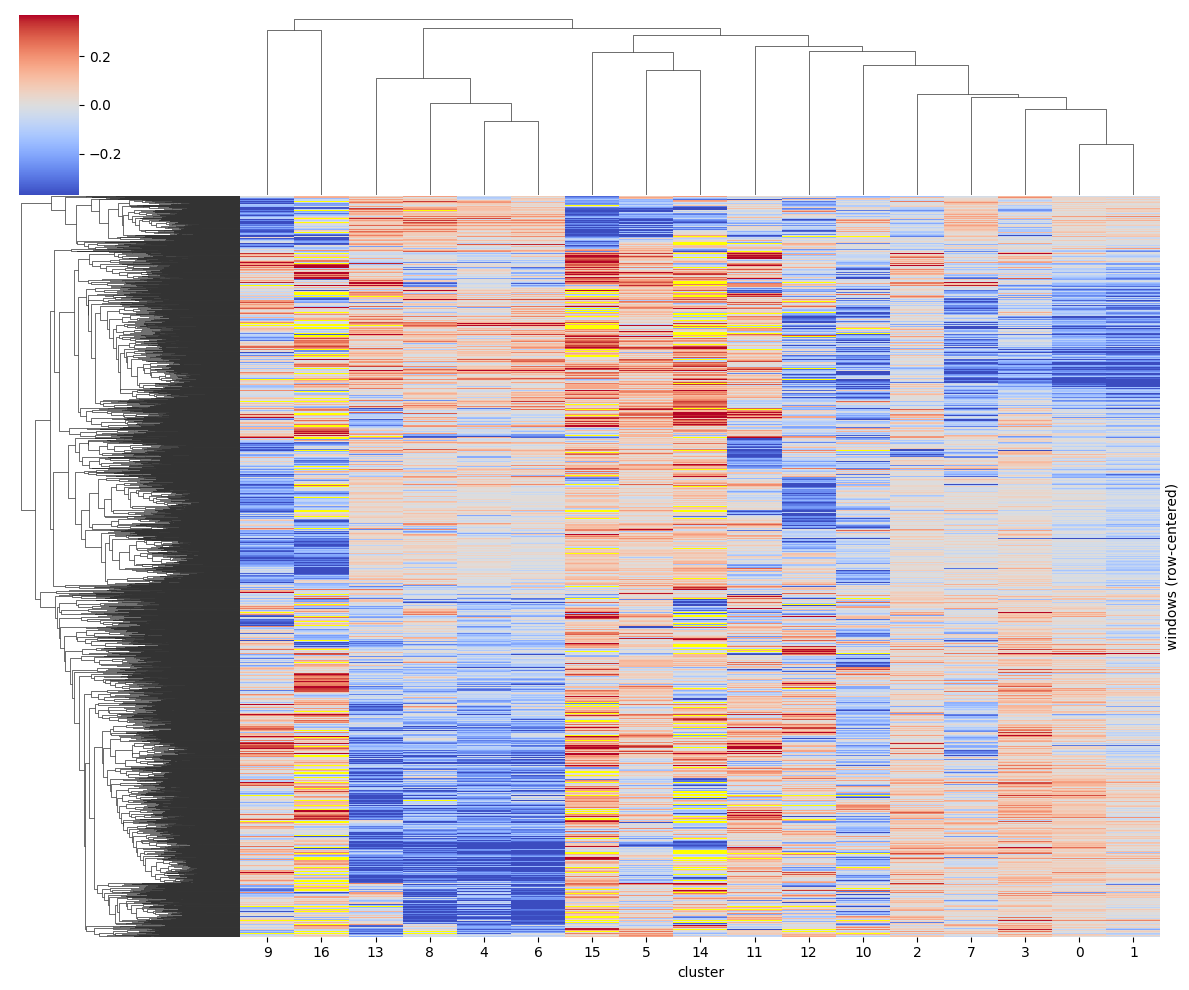

In [101]:
# 0) row-center for DISPLAY (keep NaNs here)
row_med = np.nanmedian(mat.values, axis=1, keepdims=True)
mat_centered = pd.DataFrame(mat.values - row_med, index=mat.index, columns=mat.columns)

# 1) z-score rows for CLUSTERING (safe for distances only)
row_mean = np.nanmean(mat_centered.values, axis=1, keepdims=True)
row_std  = np.nanstd(mat_centered.values, axis=1, keepdims=True)
mat_z = (mat_centered.values - row_mean) / np.where(row_std==0, 1, row_std)

# fill NaNs AFTER z-scoring (for distances only)
mat_z_filled = np.nan_to_num(mat_z, nan=0.0)

row_link = linkage(pdist(mat_z_filled,  metric='euclidean'), method='average')
col_link = linkage(pdist(mat_z_filled.T, metric='euclidean'), method='average')

# 2) colormap: show NaNs as yellow in the PLOT
cmap = sns.color_palette("coolwarm", as_cmap=True)
try:    cmap = cmap.with_extremes(bad='yellow')   # MPL ≥ 3.6
except: cmap.set_bad('yellow')                   # older MPL

# (optional) symmetric limits for better contrast
vmax = float(np.nanpercentile(np.abs(mat_centered.values), 95))
vmax = max(vmax, 1e-3)

# 3) PLOT the ORIGINAL row-centered matrix (NaNs preserved)
g = sns.clustermap(
    mat_centered,
    row_linkage=row_link,
    col_linkage=col_link,
    cmap=cmap, center=0, vmin=-vmax, vmax=vmax,
    xticklabels=True, yticklabels=False,
    figsize=(12, 10)
)
g.ax_heatmap.set_xlabel('cluster')
g.ax_heatmap.set_ylabel('windows (row-centered)')


In [112]:
mat_z_filled

array([[ 0.86807784,  0.27099667,  1.26257791, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.70764664,  0.42349267,  0.78329172, ...,  0.83954063,
         0.65527697,  0.29159868],
       [ 0.70360532,  0.75693021,  0.43084618, ..., -0.28597238,
         0.81922122,  0.47142972],
       ...,
       [ 0.89418136,  1.02110815,  0.09781808, ...,  0.        ,
         1.22582879,  0.2022256 ],
       [ 0.33729208,  0.30787073,  0.03604304, ...,  1.74376055,
         1.35616624,  1.35616624],
       [ 0.60042547,  0.27729724,  0.02396471, ..., -0.98988243,
         2.18608033,  0.97990727]])

In [54]:
# after: g = sns.clustermap(...)
row_link = g.dendrogram_row.linkage
col_link = g.dendrogram_col.linkage

row_order = g.dendrogram_row.reordered_ind   # row indices in heatmap order
col_order = g.dendrogram_col.reordered_ind   # column indices in heatmap order


In [104]:
from scipy.cluster.hierarchy import fcluster

k_rows = 30     # pick a small number to start
k_cols = 4

row_labels = fcluster(row_link, t=k_rows, criterion='maxclust')  # one label per row
col_labels = fcluster(col_link, t=k_cols, criterion='maxclust')  # one label per column


In [105]:
import numpy as np
import pandas as pd

# rows
labels_ord = row_labels[row_order]   # labels in the order you see on the heatmap
blocks = []                          # list of (label, start_row, end_row) in heatmap coords

start = 0
for i in range(1, len(labels_ord)+1):
    if i == len(labels_ord) or labels_ord[i] != labels_ord[i-1]:
        blocks.append((int(labels_ord[i-1]), start, i-1))
        start = i

# Usually each label appears once (one contiguous block). If a label appears
# multiple times, you'll just have multiple blocks with the same label.

# Nice: get the actual window coordinates for each block
win_ordered = mat_centered.index[row_order]  # MultiIndex (chr,start,end)
blocks_df = pd.DataFrame([
    {
      'row_cluster': lab,
      'heatmap_row_start': s, 'heatmap_row_end': e,
      'n_rows': e - s + 1,
      'first_window': win_ordered[s],
      'last_window':  win_ordered[e],
    }
    for (lab, s, e) in blocks
]).sort_values(['heatmap_row_start'])

print(blocks_df)


    row_cluster  heatmap_row_start  heatmap_row_end  n_rows  \
0             3                  0                0       1   
1             1                  1               11      11   
2             2                 12              241     230   
3             4                242              250       9   
4             5                251              253       3   
5             6                254             1049     796   
6             7               1050             1058       9   
7             8               1059             1095      37   
8             9               1096             1237     142   
9            10               1238             1762     525   
10           11               1763             1765       3   
11           12               1766             1784      19   
12           13               1785             1789       5   
13           14               1790             1798       9   
14           15               1799             1800    

Text(1085.5555555555559, 0.5, 'windows (row-centered)')

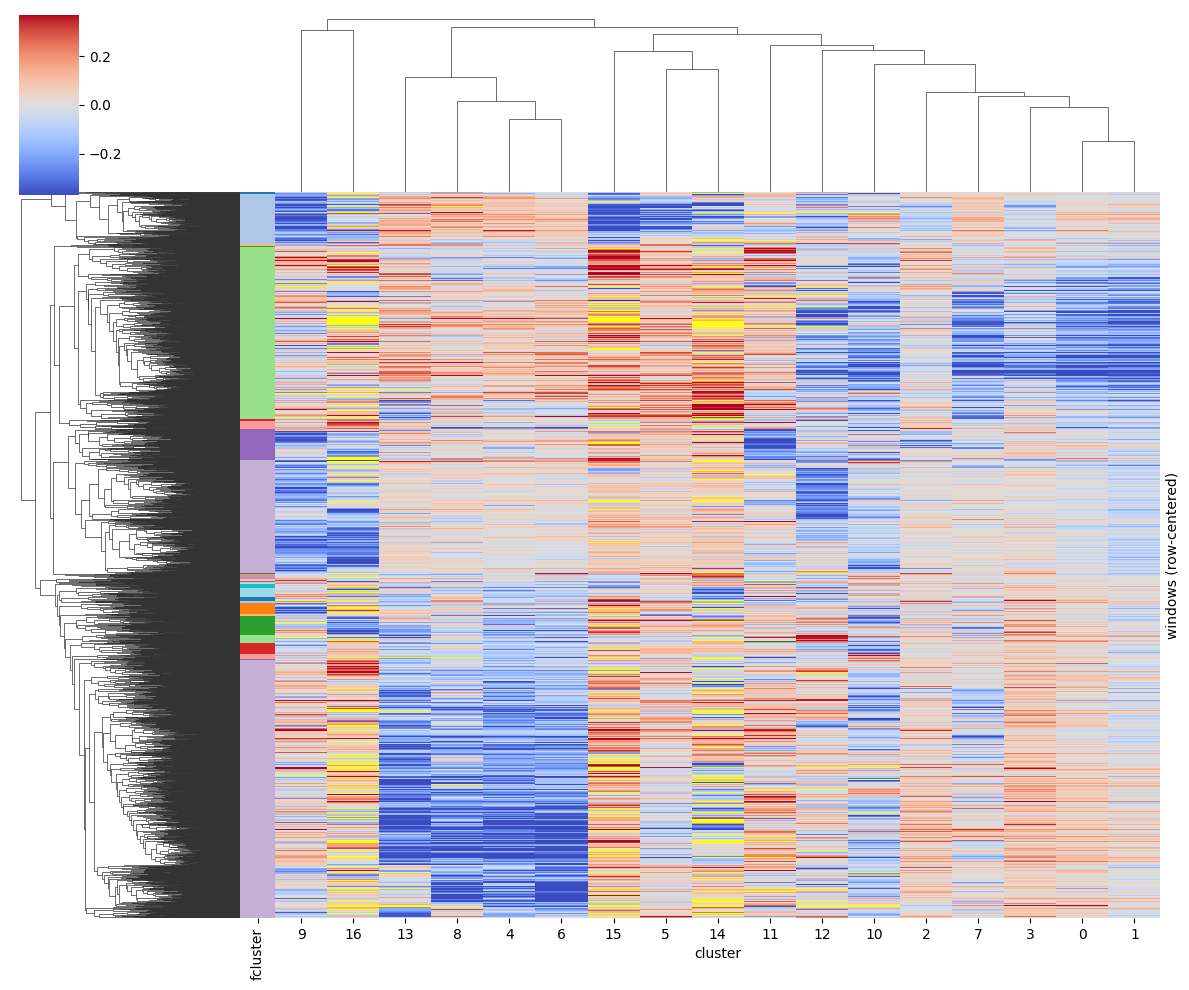

In [106]:
palette = sns.color_palette('tab20', n_colors=len(np.unique(row_labels)))
lab2col = {lab: palette[i] for i, lab in enumerate(sorted(np.unique(row_labels)))}
row_colors = pd.Series(row_labels, index=mat_centered.index).map(lab2col).to_frame('fcluster')

# 2) colormap: show NaNs as yellow in the PLOT
cmap = sns.color_palette("coolwarm", as_cmap=True)
cmap.set_bad('yellow')

# (optional) symmetric limits for better contrast
vmax = float(np.nanpercentile(np.abs(mat_centered.values), 95))
vmax = max(vmax, 1e-3)

# 3) PLOT the ORIGINAL row-centered matrix (NaNs preserved)
g = sns.clustermap(
    mat_centered,
    row_linkage=row_link,
    col_linkage=col_link,
    row_colors=row_colors,
    cmap=cmap, center=0, vmin=-vmax, vmax=vmax,
    xticklabels=True, yticklabels=False,
    figsize=(12, 10)
)
g.ax_heatmap.set_xlabel('cluster')
g.ax_heatmap.set_ylabel('windows (row-centered)')

In [91]:
#blue block around 13-8-4-6

# 2) Reorder your matrix exactly as shown in the heatmap
M = mat.iloc[row_order, col_order]   # rows = windows; cols = cluster labels

# 3) Slice the row range you want (2238–3356 inclusive)
r0, r1 = 2238, 3356
rows_slice = M.iloc[r0:r1+1, :]

# 4) Keep only the desired clusters (13, 8, 4, 6) — in that order if present
wanted = [13, 8, 4, 6]
# if your columns are strings, coerce wanted to that dtype:
# wanted = list(map(str, wanted))
have = [c for c in wanted if c in rows_slice.columns]
sub = rows_slice.loc[:, have]

# 5) Get the genomic coords (chr, start, end) for these rows
win_coords = sub.index.to_frame(index=False)  # MultiIndex -> 3 columns
win_coords

,chr,start,end
0,4,7420301,7420400
1,1,12922001,12922100
2,5,15579001,15579100
3,5,3253301,3253400
4,3,7653601,7653700
...,...,...,...
1114,3,12350401,12350500
1115,3,15517001,15517100
1116,4,9524201,9524300
1117,1,11739101,11739200


In [92]:
sub

cluster                    13      8       4       6 
chr start    end                                     
4   7420301  7420400   0.0508  0.0652  0.1711  0.0758
1   12922001 12922100  0.7647  0.6667  0.6907  0.7576
5   15579001 15579100  0.5000  0.4884  0.4017  0.4259
    3253301  3253400   0.5357  0.3500  0.2131  0.3953
3   7653601  7653700   0.1224  0.0816  0.1283  0.0619
...                       ...     ...     ...     ...
    12350401 12350500  0.4231  0.7188  0.6250  0.6790
    15517001 15517100  0.0000  0.0698  0.0865  0.0696
4   9524201  9524300   0.4722  0.7632  0.5339  0.6625
1   11739101 11739200  0.0732  0.2381  0.1868  0.2171
3   10172001 10172100  0.4419  0.7368  0.5097  0.5109

[1119 rows x 4 columns]

In [107]:
sub.to_csv("/ceph/MethDev/pbio/kay/data/heatmap_rows_2238_3356_clusters_13_8_4_6.tsv", sep="\t")

In [109]:
#blue block around 9-15

# 2) Reorder your matrix exactly as shown in the heatmap
M = mat.iloc[row_order, col_order]   # rows = windows; cols = cluster labels

# 3) Slice the row range you want (2238–3356 inclusive)
r0, r1 = 0, 230
rows_slice = M.iloc[r0:r1+1, :]

# 4) Keep only the desired clusters (13, 8, 4, 6) — in that order if present
wanted = [13, 8, 4, 6]
# if your columns are strings, coerce wanted to that dtype:
# wanted = list(map(str, wanted))
have = [c for c in wanted if c in rows_slice.columns]
sub = rows_slice.loc[:, have]

# 5) Get the genomic coords (chr, start, end) for these rows
win_coords = sub.index.to_frame(index=False)  # MultiIndex -> 3 columns
sub

cluster                    13      8       4       6 
chr start    end                                     
2   5814501  5814600   0.7222  0.3833  0.5235  0.4626
1   24369101 24369200  0.5000  0.6667  0.2703  0.1250
4   11349401 11349500  0.4516  0.7609  0.5357  0.5097
5   19151401 19151500  0.5769  0.7792  0.6271  0.5802
    24723501 24723600  0.8636  1.0000  0.7805  0.8944
...                       ...     ...     ...     ...
2   4162401  4162500   0.9184  0.8632  0.9042  0.8370
    5846701  5846800   0.9070  0.9136  0.8945  0.9048
3   14835801 14835900  0.8927  0.9308  0.9257  0.8818
1   281901   282000    0.8919  0.9189  0.8182  0.9155
2   2766001  2766100   0.6207  0.9556  0.8343  0.9540

[231 rows x 4 columns]

In [111]:
M.to_csv("/ceph/MethDev/pbio/kay/data/heathmap_rows.tsv", sep="\t")

In [95]:
mat_centered

cluster                     0        1        2        3        4        5   \
chr start    end                                                              
1   76901    77000     0.10365  0.00845  0.16655 -0.00845 -0.28845  0.19155   
    77001    77100     0.05860  0.00000  0.07420  0.09220 -0.56360  0.04460   
    77201    77300     0.05780  0.06910  0.00000  0.10900 -0.54780  0.04990   
    281801   281900    0.04250  0.01690 -0.05350  0.01070  0.00550  0.00000   
    281901   282000    0.02800  0.00410 -0.09770  0.01670 -0.09730  0.03900   
...                        ...      ...      ...      ...      ...      ...   
5   26885901 26886000  0.07260  0.03540  0.04160  0.06460 -0.20740  0.14620   
    26886001 26886100  0.14295 -0.00665  0.00665  0.21235 -0.21475  0.21235   
    26886101 26886200  0.08935  0.10175  0.01155  0.10745 -0.20175  0.17555   
    26886201 26886300  0.03680  0.03220 -0.01030  0.09410 -0.23460 -0.05680   
    26886301 26886400  0.11150  0.04900  0.00000  0.08390 -0.28760 -0.02830   

cluster                     6        7        8        9        10       11  \
chr start    end                                                              
1   76901    77000    -0.28215  0.04345 -0.20845 -0.18345      NaN  0.04865   
    77001    77100    -0.28100 -0.01670 -0.42720  0.03770 -0.13150  0.07020   
    77201    77300    -0.04840 -0.02800 -0.30190  0.12400 -0.29030  0.12400   
    281801   281900   -0.03320  0.03130  0.06330 -0.18670  0.01450 -0.09460   
    281901   282000    0.00000 -0.01940  0.00340 -0.18820 -0.08220 -0.04760   
...                        ...      ...      ...      ...      ...      ...   
5   26885901 26886000 -0.09880 -0.22110 -0.07890  0.19500 -0.03540  0.08250   
    26886001 26886100 -0.02545 -0.13065 -0.06265  0.37145 -0.13765  0.18455   
    26886101 26886200 -0.06425 -0.05755 -0.11685  0.03155 -0.01875 -0.05825   
    26886201 26886300 -0.22350 -0.11260 -0.27060 -0.03820  0.10080  0.00000   
    26886301 26886400 -0.24850 -0.05830 -0.06910 -0.03180  0.03820  0.20000   

cluster                     12       13      14       15       16  
chr start    end                                                   
1   76901    77000    -0.00845      NaN     NaN      NaN      NaN  
    77001    77100    -0.08810 -0.46050  0.0858  0.04780 -0.02720  
    77201    77300    -0.31350 -0.49500 -0.1519  0.08230  0.00860  
    281801   281900   -0.15100 -0.00810 -0.0276 -0.19760  0.02330  
    281901   282000    0.08450 -0.02360  0.0559 -0.16550  0.05220  
...                        ...      ...     ...      ...      ...  
5   26885901 26886000 -0.10210 -0.27880 -0.0425  0.26460      NaN  
    26886001 26886100 -0.13765 -0.14375     NaN  0.46235  0.46235  
    26886101 26886200 -0.01155 -0.09985     NaN  0.12175  0.02175  
    26886201 26886300  0.00770 -0.24480  0.2567  0.19610  0.19610  
    26886301 26886400  0.14320 -0.38800 -0.1961  0.41820  0.18490  

[3357 rows x 17 columns]

In [61]:
# # rows
# cid = 2
# rows_mask = (row_labels == cid)
# win_idx = mat_centered.index[rows_mask]                 # windows (unordered)
# win_idx_in_heatmap_order = win_ordered[labels_ord == cid]  # windows as shown (contiguous block)

# # columns
# cols_annot = pd.Series(col_labels, index=mat_centered.columns, name='col_cluster')
# col_group = cols_annot.index[cols_annot.eq(1)]


In [49]:
# Attach row cluster ids to each window (row)
rows_annot = mat_centered.copy()
rows_annot['row_cluster'] = row_labels

# See how many windows per row-cluster
rows_annot['row_cluster'].value_counts().sort_index()


row_cluster
1     242
2     854
3     689
4      23
5    1549
Name: count, dtype: int64

In [50]:
cid = 1  # e.g., row-cluster 1
win_idx = rows_annot.index[rows_annot['row_cluster'] == cid]   # MultiIndex of (chr,start,end)

# As a small table of coordinates:
win_coords = win_idx.to_frame(index=False)  # columns: chr, start, end
print(win_coords.head(10))


   chr     start       end
0    1    281901    282000
1    1   4061601   4061700
2    1   5062601   5062700
3    1   5867201   5867300
4    1  19706701  19706800
5    1  23212201  23212300
6    1  23212301  23212400
7    1  24369101  24369200
8    1  24643401  24643500
9    2      8201      8300


In [51]:
cols_annot = pd.Series(col_labels, index=mat_centered.columns, name='col_cluster')
cols_annot.value_counts().sort_index()

col_group = cols_annot.index[cols_annot == 1]  # columns in column-cluster 1
submat_rc = mat_centered.loc[win_idx, col_group]


In [53]:
submat_rc

cluster                    9       16
chr start    end                     
1   281901   282000   -0.1882  0.0522
    4061601  4061700  -0.3067 -0.1587
    5062601  5062700  -0.1443  0.2057
    5867201  5867300  -0.0468 -0.0420
    19706701 19706800  0.1035 -0.0608
...                       ...     ...
5   20219001 20219100 -0.3047 -0.1928
    22223401 22223500 -0.2206 -0.2149
    23310401 23310500 -0.1259 -0.2000
    23310501 23310600 -0.0882 -0.1515
    24723501 24723600  0.0000  0.1289

[242 rows x 2 columns]

In [16]:
# After you built the clustermap:
# g = sns.clustermap(...)

row_order = g.dendrogram_row.reordered_ind
col_order = g.dendrogram_col.reordered_ind


In [18]:
len(row_order)

3357

In [19]:

mat_ordered = mat_centered.iloc[row_order, col_order]   # colors you plotted
win_ordered = mat_ordered.index                         # MultiIndex (chr,start,end)



In [20]:
mat_ordered

cluster                     9        16       13       8        4        6   \
chr start    end                                                              
2   5814501  5814600  -0.07410  0.05730  0.20810 -0.13080  0.00940 -0.05150   
1   24369101 24369200  0.04400      NaN -0.01160  0.15510 -0.24130 -0.38660   
4   11349401 11349500 -0.09570  0.00540 -0.09860  0.21070 -0.01450 -0.04050   
5   19151401 19151500 -0.09010  0.00000 -0.07020  0.13210 -0.02000 -0.06690   
    24723501 24723600  0.00000  0.12890  0.04010  0.17650 -0.04300  0.07090   
...                        ...      ...      ...      ...      ...      ...   
3   12350401 12350500 -0.07165  0.01765 -0.27355  0.02215 -0.07165 -0.01765   
    15517001 15517100  0.00980  0.02260 -0.10780 -0.03800 -0.02130 -0.03820   
4   9524201  9524300  -0.08555 -0.06925 -0.22205  0.06895 -0.16035 -0.03175   
1   11739101 11739200  0.00210  0.03970 -0.19740 -0.03250 -0.08380 -0.05350   
3   10172001 10172100 -0.09740      NaN -0.27090  0.02400 -0.20310 -0.20190   

cluster                     15       5        14       11       12       10  \
chr start    end                                                              
2   5814501  5814600  -0.03790  0.01400 -0.08550  0.00590  0.03140  0.15260   
1   24369101 24369200 -0.41160 -0.17830 -0.28940  0.32170  0.08840      NaN   
4   11349401 11349500 -0.11270  0.04410 -0.19020  0.03420  0.16650 -0.02940   
5   19151401 19151500 -0.28350  0.10090 -0.19260  0.23800  0.27130 -0.03490   
    24723501 24723600 -0.32350  0.08060  0.17650  0.02650 -0.03780 -0.18710   
...                        ...      ...      ...      ...      ...      ...   
3   12350401 12350500 -0.12525  0.19465      NaN  0.12945  0.30335 -0.12525   
    15517001 15517100 -0.03370  0.21160  0.06870  0.04840  0.22550 -0.07450   
4   9524201  9524300       NaN  0.08355  0.30575 -0.02755  0.30575  0.00575   
1   11739101 11739200  0.09050  0.16940  0.03890 -0.06470  0.16180 -0.07910   
3   10172001 10172100  0.21030  0.23660  0.28720 -0.00450  0.25690 -0.12100   

cluster                     2        7        3        0        1   
chr start    end                                                    
2   5814501  5814600  -0.00130  0.09950  0.00000 -0.10450 -0.10320  
1   24369101 24369200  0.01780  0.15510  0.40140 -0.08810  0.00000  
4   11349401 11349500  0.05830  0.05070  0.01430  0.00000 -0.06790  
5   19151401 19151500  0.10450 -0.05730  0.19150  0.06940  0.00370  
    24723501 24723600 -0.13300 -0.02350  0.12040 -0.02660 -0.02070  
...                        ...      ...      ...      ...      ...  
3   12350401 12350500  0.02235 -0.12085  0.24565  0.07075 -0.02995  
    15517001 15517100  0.09090 -0.01770  0.06920  0.00000 -0.00890  
4   9524201  9524300   0.18525 -0.01685  0.14395  0.07615 -0.00575  
1   11739101 11739200  0.09200 -0.05270  0.09630  0.00000 -0.03270  
3   10172001 10172100  0.15340 -0.04610  0.14800  0.00450 -0.10300  

[3357 rows x 17 columns]

In [21]:
# Save for inspection
mat_ordered.to_csv("/ceph/MethDev/pbio/kay/data/clustermap_matrix.tsv", sep="\t")


In [22]:
import numpy as np
import pandas as pd

M = mat_centered  # or mat_z, or mat (absolute) — match your plot

# Option A: fixed thresholds
pos_thr, neg_thr = 0.25, -0.25     # tune to your scale
min_hits = 3                       # require ≥3 clusters exceed threshold

# Option B: data-driven thresholds (90th/10th percentiles)
# q = np.nanpercentile(M.values, [10, 90])
# neg_thr, pos_thr = q[0], q[1]

pos_hits = (M >= pos_thr).sum(axis=1)
neg_hits = (M <= neg_thr).sum(axis=1)

ext_summary = pd.DataFrame({
    'pos_hits': pos_hits,
    'neg_hits': neg_hits,
    'max_val':  np.nanmax(M.values, axis=1),
    'min_val':  np.nanmin(M.values, axis=1),
    'range':    np.nanmax(M.values, axis=1) - np.nanmin(M.values, axis=1),
    'l2':       np.sqrt(np.nanmean(M.values**2, axis=1)),       # overall magnitude
    'mad':      np.nanmedian(np.abs(M.values - np.nanmedian(M.values,1,keepdims=True)), axis=1)
}, index=M.index)

# Strong positive / negative windows
strong_pos = ext_summary[(ext_summary['pos_hits'] >= min_hits)].sort_values(['pos_hits','max_val'], ascending=[False,False])
strong_neg = ext_summary[(ext_summary['neg_hits'] >= min_hits)].sort_values(['neg_hits','min_val'], ascending=[False,True])

# Keep the clustermap order
strong_pos = strong_pos.loc[win_ordered.intersection(strong_pos.index)]
strong_neg = strong_neg.loc[win_ordered.intersection(strong_neg.index)]

# Peek
strong_pos.head(), strong_neg.head()


(                     pos_hits  neg_hits  max_val  min_val   range        l2  \
 chr start   end                                                               
 2   3501901 3502000         3         4   0.2548  -0.6452  0.9000  0.269193   
     3500901 3501000         3         2   0.3487  -0.4094  0.7581  0.201243   
     3486001 3486100         3         0   0.3512  -0.2404  0.5916  0.180659   
     3381801 3381900         3         2   0.3231  -0.4769  0.8000  0.225792   
     3447501 3447600         3         2   0.3607  -0.4393  0.8000  0.244413   
 
                         mad  
 chr start   end              
 2   3501901 3502000  0.1516  
     3500901 3501000  0.1132  
     3486001 3486100  0.1426  
     3381801 3381900  0.1954  
     3447501 3447600  0.2107  ,
                        pos_hits  neg_hits  max_val  min_val   range        l2  \
 chr start    end                                                                
 1   24369101 24369200         2         3   0.4014  -0.

In [23]:
strong_pos

pos_hits  neg_hits  max_val  min_val   range        l2  \
chr start    end                                                                
2   3501901  3502000          3         4  0.25480 -0.64520  0.9000  0.269193   
    3500901  3501000          3         2  0.34870 -0.40940  0.7581  0.201243   
    3486001  3486100          3         0  0.35120 -0.24040  0.5916  0.180659   
    3381801  3381900          3         2  0.32310 -0.47690  0.8000  0.225792   
    3447501  3447600          3         2  0.36070 -0.43930  0.8000  0.244413   
...                         ...       ...      ...      ...     ...       ...   
5   18065201 18065300         3         0  0.32210 -0.23280  0.5549  0.164789   
4   11657701 11657800         3         3  0.29000 -0.30140  0.5914  0.195690   
2   1567301  1567400          3         3  0.26785 -0.61455  0.8824  0.257417   
3   10393801 10393900         3         1  0.59530 -0.28570  0.8810  0.270495   
5   15259801 15259900         3         1  0.38550 -0.33330  0.7188  0.196509   

                           mad  
chr start    end                
2   3501901  3502000   0.15160  
    3500901  3501000   0.11320  
    3486001  3486100   0.14260  
    3381801  3381900   0.19540  
    3447501  3447600   0.21070  
...                        ...  
5   18065201 18065300  0.10950  
4   11657701 11657800  0.16500  
2   1567301  1567400   0.08710  
3   10393801 10393900  0.20520  
5   15259801 15259900  0.16065  

[257 rows x 7 columns]

In [24]:
strong_neg

,,,pos_hits,neg_hits,max_val,min_val,range,l2,mad
chr,start,end,,,,,,,
1,24369101,24369200,2,3,0.4014,-0.4116,0.8130,0.234284,0.1551
5,7475201,7475300,0,3,0.0399,-0.6134,0.6533,0.183666,0.0287
2,3501901,3502000,3,4,0.2548,-0.6452,0.9000,0.269193,0.1516
1,23212201,23212300,0,3,0.1186,-0.4269,0.5455,0.171504,0.1077
2,3429101,3429200,0,3,0.1733,-0.6391,0.8124,0.214611,0.0766
...,...,...,...,...,...,...,...,...,...
4,6302901,6303000,0,4,0.2456,-0.3973,0.6429,0.188071,0.1206
5,14281401,14281500,2,3,0.2500,-0.3056,0.5556,0.185029,0.1136
1,20332701,20332800,0,3,0.1700,-0.2900,0.4600,0.147489,0.0814


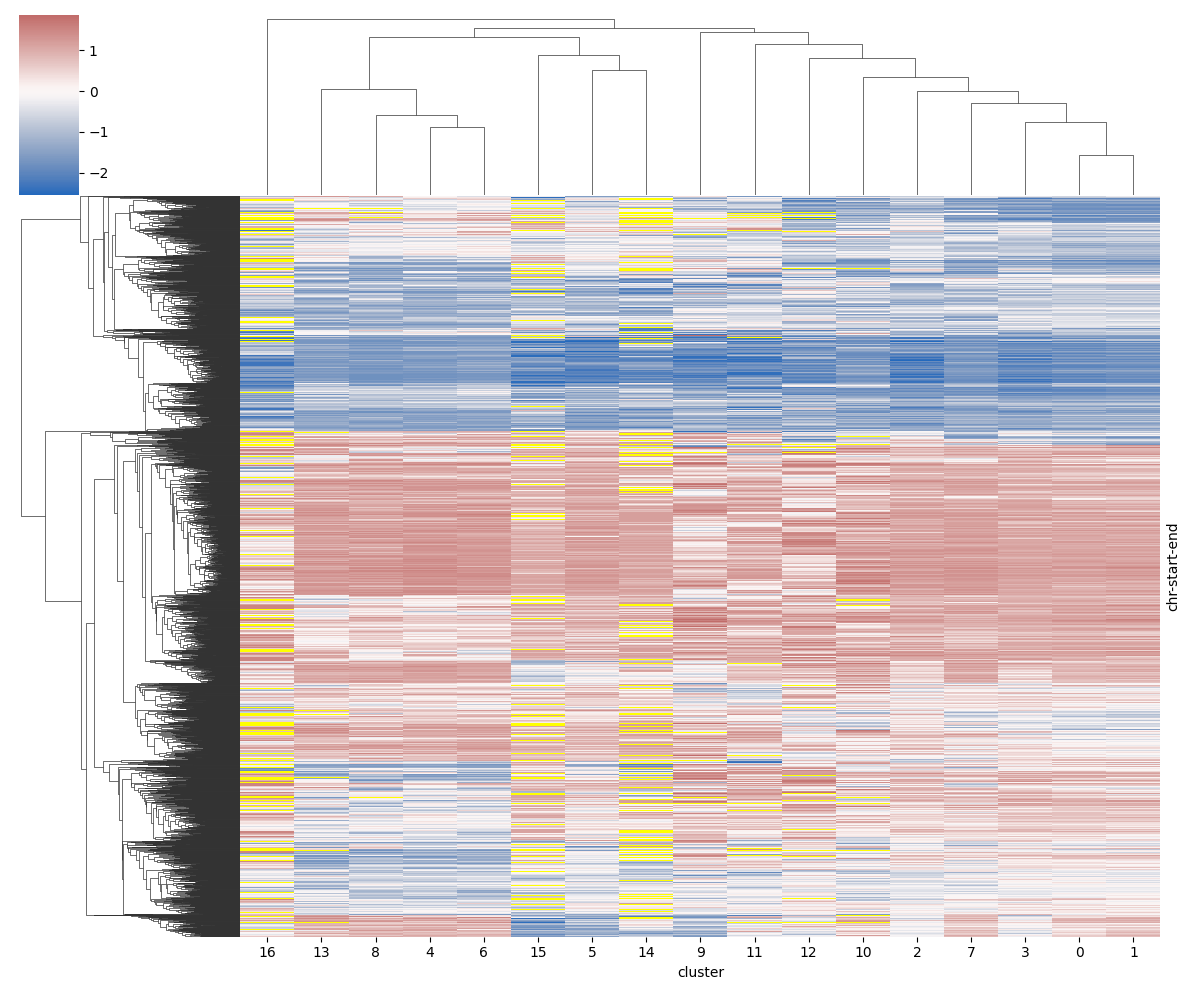

In [37]:
# # mat: windows × clusters with NaNs for low coverage

# # --- column-wise z-score for COLORING (keep NaNs so they show as grey) ---
# col_mean = np.nanmean(mat.values, axis=0, keepdims=True)
# col_std  = np.nanstd(mat.values, axis=0, keepdims=True)
# mat_colz = pd.DataFrame((mat.values - col_mean) / np.where(col_std==0, 1, col_std),
#                         index=mat.index, columns=mat.columns)

# # For clustering ONLY (finite distances), fill AFTER z-scoring
# mat_colz_filled = np.nan_to_num(mat_colz.values, nan=0.0)

# from scipy.cluster.hierarchy import linkage
# from scipy.spatial.distance import pdist
# row_link = linkage(pdist(mat_colz_filled,  metric='euclidean'), method='average')
# col_link = linkage(pdist(mat_colz_filled.T, metric='euclidean'), method='average')

# # Plot with NaNs preserved (so they render grey/yellow as you set)
# cmap = sns.color_palette("vlag", as_cmap=True)  # includes yellow; or keep your cmap
# try:    cmap = cmap.with_extremes(bad='yellow')
# except: cmap.set_bad('yellow')

# g = sns.clustermap(
#     mat_colz,                      # <-- COLORS now = column z-scores
#     row_linkage=row_link, col_linkage=col_link,
#     cmap=cmap, center=0,           # 0 = column (cluster) average across windows
#     xticklabels=True, yticklabels=False, figsize=(12,10)
# )


In [26]:
# after g = sns.clustermap(...)
row_link = g.dendrogram_row.linkage
col_link = g.dendrogram_col.linkage


In [27]:
row_link

array([[5.35000000e+02, 3.17800000e+03, 8.90821423e-01, 2.00000000e+00],
       [7.63000000e+02, 3.25200000e+03, 9.19988727e-01, 2.00000000e+00],
       [1.12600000e+03, 1.29300000e+03, 9.20104381e-01, 2.00000000e+00],
       ...,
       [6.70400000e+03, 6.70500000e+03, 5.65161455e+00, 1.57200000e+03],
       [6.70900000e+03, 6.71000000e+03, 5.80587696e+00, 3.11500000e+03],
       [6.70800000e+03, 6.71100000e+03, 6.19289595e+00, 3.35700000e+03]])

In [28]:
from scipy.cluster.hierarchy import fcluster

k_rows = 6    # choose how many window clusters you want
k_cols = 4    # (optional) how many groups of cell clusters

row_labels = fcluster(row_link, t=k_rows, criterion='maxclust')   # length = n_rows
col_labels = fcluster(col_link, t=k_cols, criterion='maxclust')   # length = n_cols

# Attach labels to convenient tables
rows_annot = (mat_centered
              .assign(row_cluster=row_labels)
              .rename_axis(['chr','start','end']))        # keep genomic coords

cols_annot = pd.DataFrame({'cluster': mat_centered.columns,
                           'col_cluster': col_labels}).set_index('cluster')


In [29]:
# Pick, say, row-cluster 3
cid = 3
win_idx = rows_annot.index[rows_annot['row_cluster'] == cid]  # list of (chr,start,end)
sub = mat_centered.loc[win_idx]                                # windows in this group

print(f"Row cluster {cid}: {len(sub)} windows")
print("A few members:")
print(pd.DataFrame(win_idx, columns=['chr','start','end']).head())

# Aggregate profile across cell clusters (mean pattern for this window-cluster)
profile = np.nanmean(sub.values, axis=0)                       # length = n_clusters
profile = pd.Series(profile, index=mat_centered.columns)
profile.head()


Row cluster 3: 854 windows
A few members:


ValueError: Shape of passed values is (854, 1), indices imply (854, 3)